In [1]:
%pip install numpy gymnasium scikit-learn torch pandas treeple matplotlib ydf


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
import ydf
from ydf import GradientBoostedTreesLearner

## Data Generation

In [3]:
# environment setup
# session_duration = 500000
# env_name = 'ForagingPlaygroundLinear-v0'
# register_custom_env(
#     env_name = env_name, 
#     map_name = 'short',
#     base_reward = 10.0,
#     decay_rate = 0.6,
#     reward_period = 10,
#     session_duration = session_duration
# )
# env = gym.make(env_name)

base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)




In [4]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


## PAFM with Postional Encoding

## PAFM optimal

25
(150, 57) (150,)
Train model on 150 examples
Model trained in 0:00:00.274256
128 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.3095636791631846


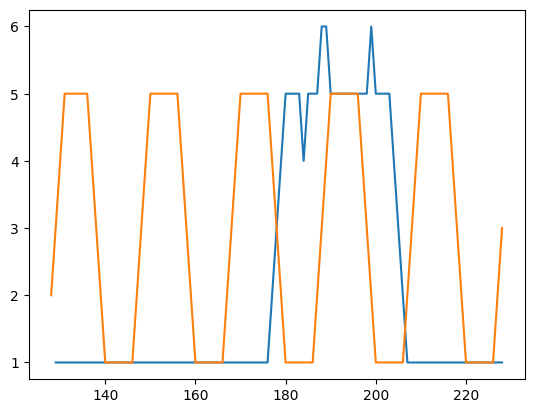

51
(306, 57) (306,)
Train model on 306 examples
Model trained in 0:00:00.218461
256 train done
0.950065968268637


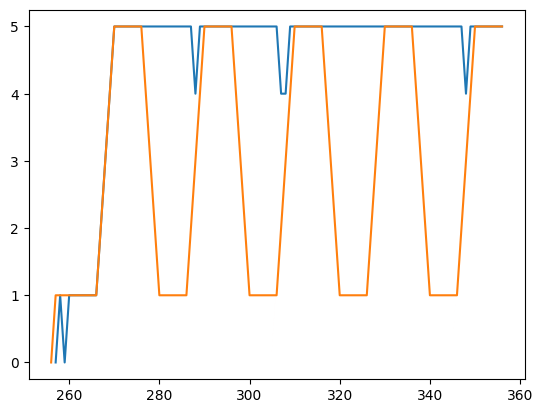

102
(612, 57) (612,)
Train model on 612 examples
Model trained in 0:00:00.287641
512 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


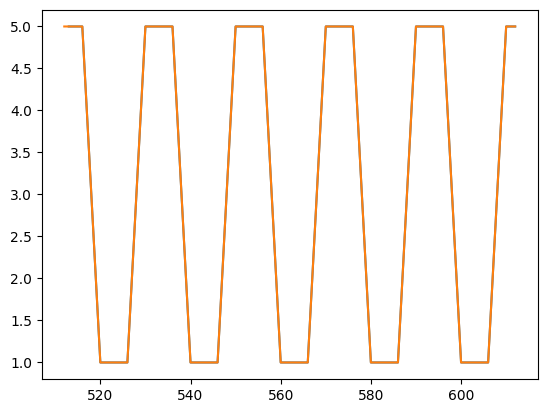

150
(900, 57) (900,)
Train model on 900 examples
Model trained in 0:00:00.348794
750 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.19403728927541608


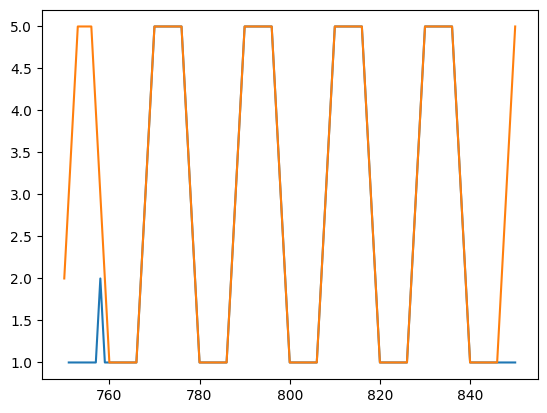

204
(1224, 57) (1224,)
Train model on 1224 examples
Model trained in 0:00:01.108344
1024 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


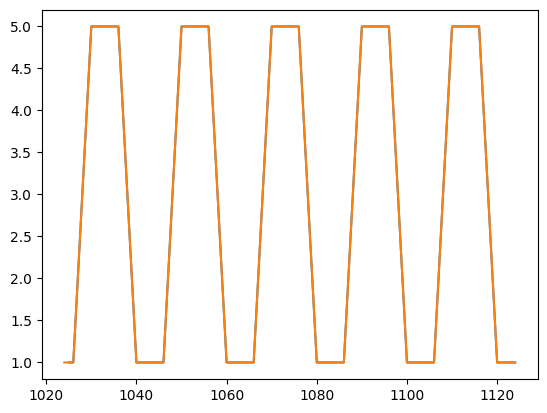

250
(1500, 57) (1500,)
Train model on 1500 examples
Model trained in 0:00:00.430690
1250 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.03934980000000024


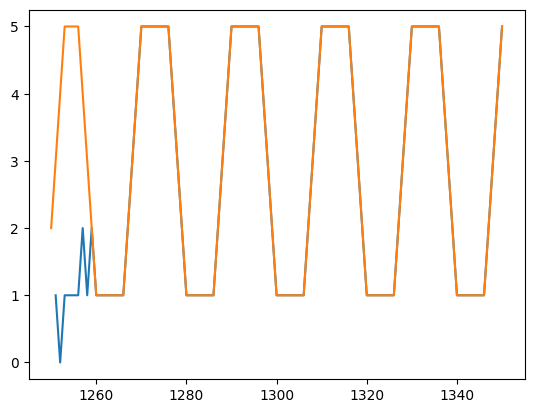

300
(1800, 57) (1800,)
Train model on 1800 examples
Model trained in 0:00:00.539743
1500 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


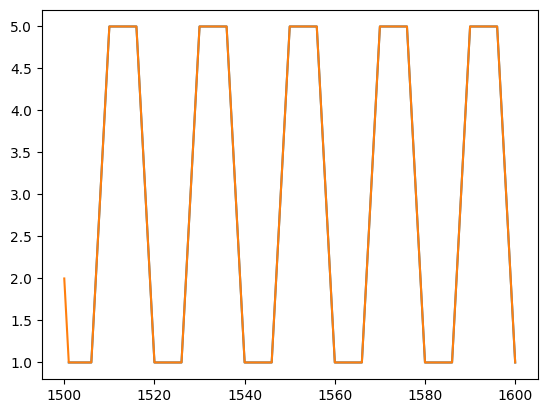

409
(2454, 57) (2454,)
Train model on 2454 examples
Model trained in 0:00:00.855904
2048 train done
0.0


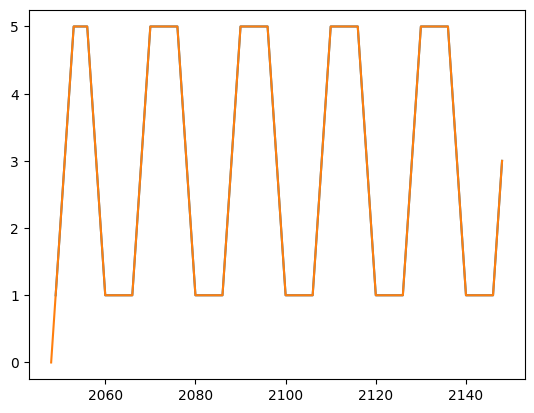

25
(150, 57) (150,)
Train model on 150 examples
Model trained in 0:00:00.125318
128 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.1902863976706262


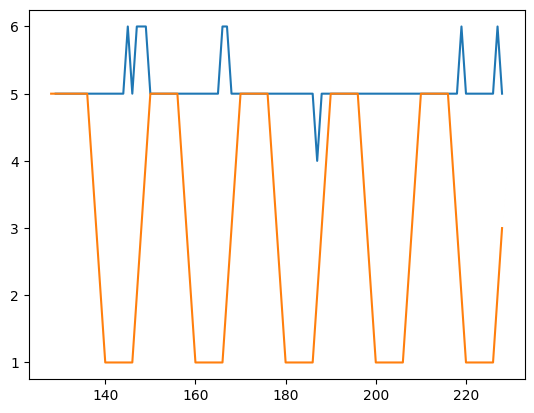

51
(306, 57) (306,)
Train model on 306 examples
Model trained in 0:00:00.251309
256 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


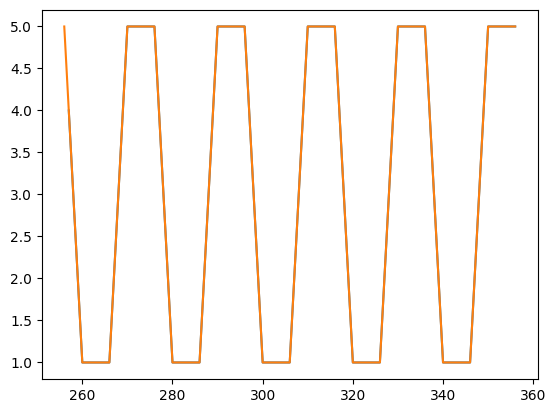

102
(612, 57) (612,)
Train model on 612 examples
Model trained in 0:00:00.182612
512 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.284451200423888


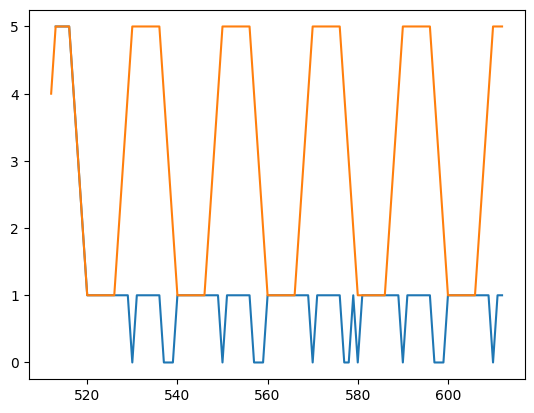

150
(900, 57) (900,)
Train model on 900 examples
Model trained in 0:00:00.356859
750 train done
0.0


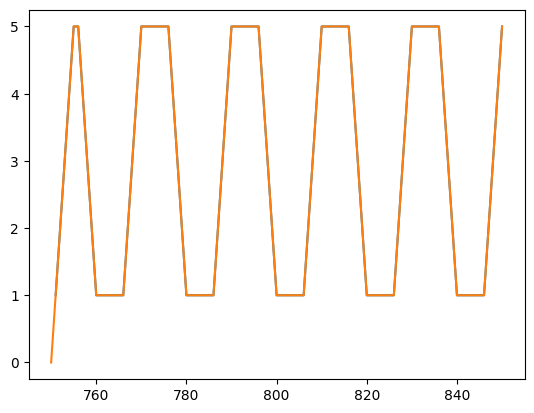

204
(1224, 57) (1224,)
Train model on 1224 examples
Model trained in 0:00:01.019587
1024 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.2385191537681888


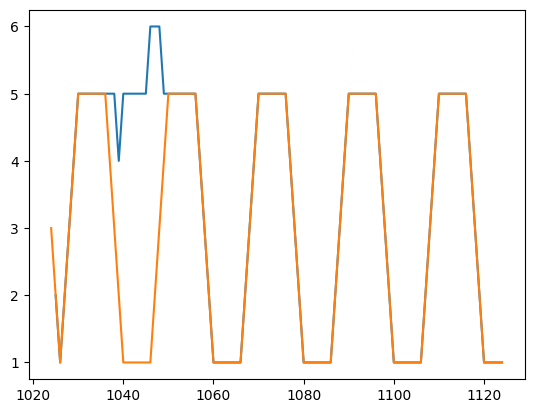

250
(1500, 57) (1500,)
Train model on 1500 examples
Model trained in 0:00:01.290411
1250 train done
0.0


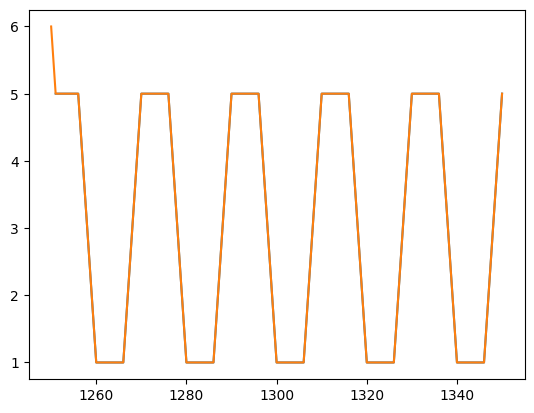

300
(1800, 57) (1800,)
Train model on 1800 examples
Model trained in 0:00:01.226473
1500 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.011340000000000145


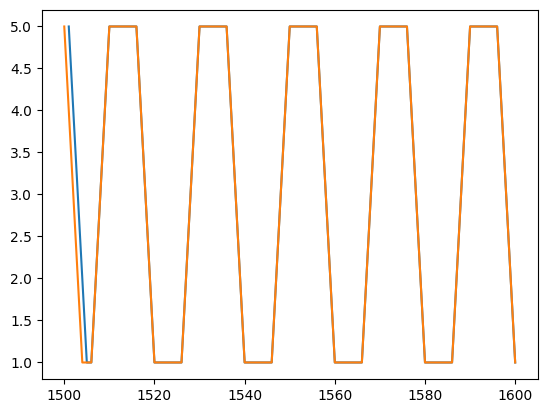

409
(2454, 57) (2454,)
Train model on 2454 examples
Model trained in 0:00:00.557859
2048 train done
0.04508865000000015


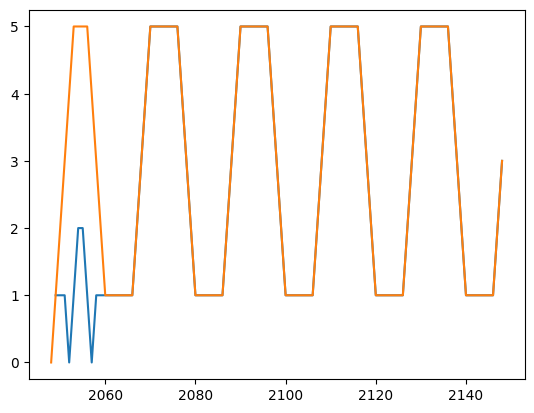

25
(150, 57) (150,)
Train model on 150 examples
Model trained in 0:00:00.356150
128 train done
0.9890543079618542


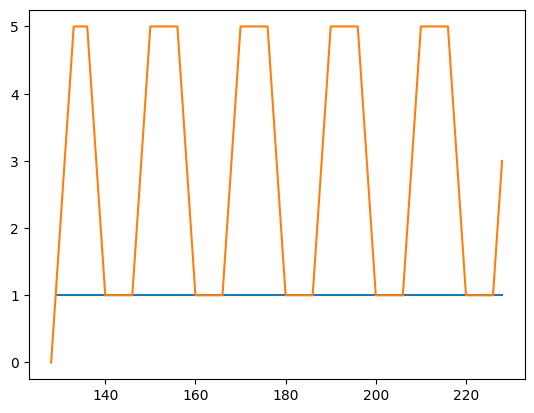

51
(306, 57) (306,)
Train model on 306 examples
Model trained in 0:00:00.197391
256 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.1961347349263634


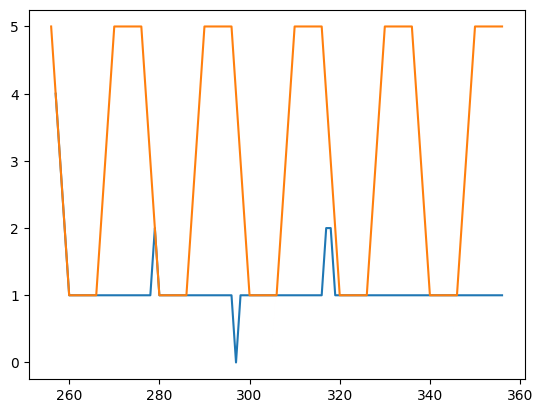

102
(612, 57) (612,)
Train model on 612 examples
Model trained in 0:00:00.253815
512 train done
0.7126498485603673


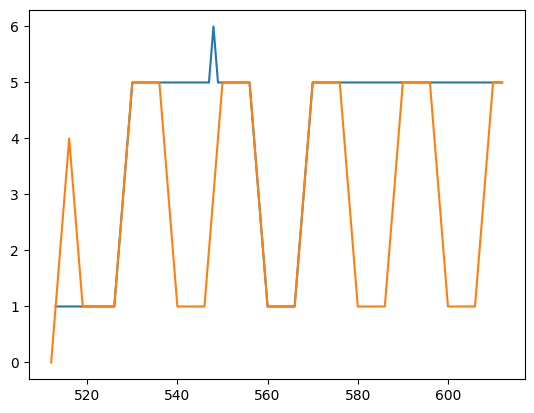

150
(900, 57) (900,)
Train model on 900 examples
Model trained in 0:00:00.370756
750 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


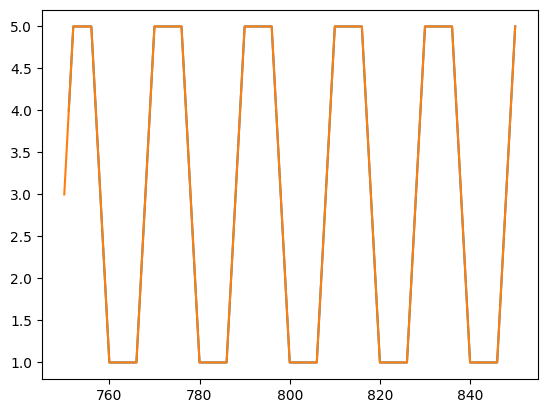

204
(1224, 57) (1224,)
Train model on 1224 examples
Model trained in 0:00:00.597112
1024 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


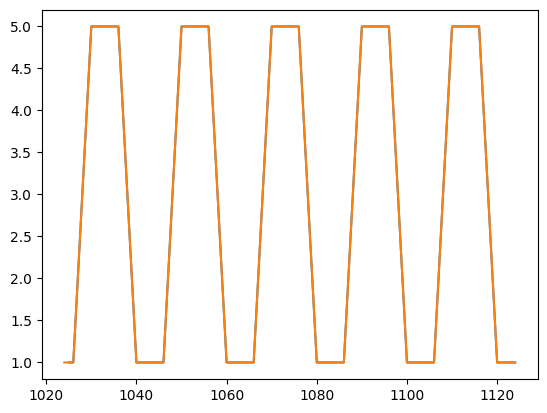

250
(1500, 57) (1500,)
Train model on 1500 examples
Model trained in 0:00:01.002696
1250 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0231498000000002


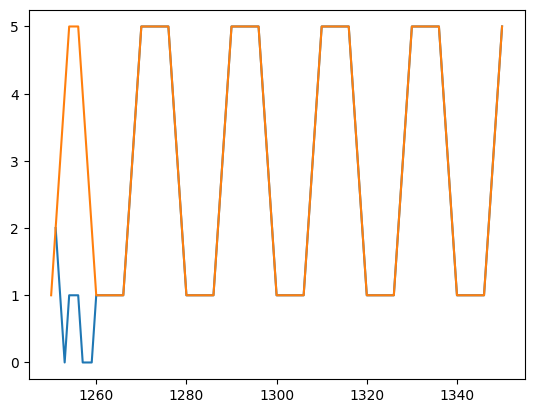

300
(1800, 57) (1800,)
Train model on 1800 examples
Model trained in 0:00:01.175698
1500 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


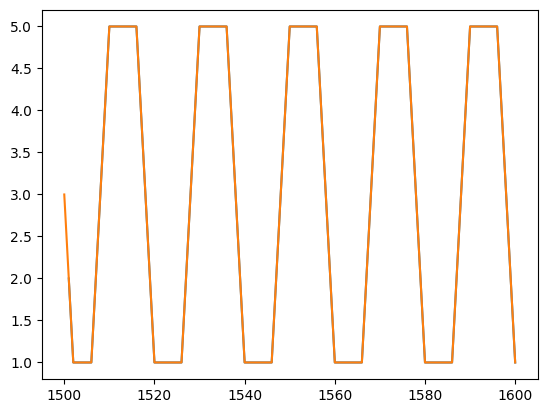

409
(2454, 57) (2454,)
Train model on 2454 examples
Model trained in 0:00:00.517324
2048 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


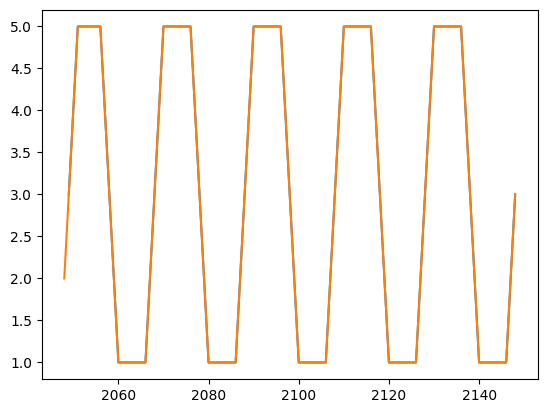

25
(150, 57) (150,)
Feature feature_0 is a NUMERICAL feature with all values recorded in the data spec set to the same value. The feature will likely not be useful during model training.
Train model on 150 examples
Model trained in 0:00:00.085633
128 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.275606676799799


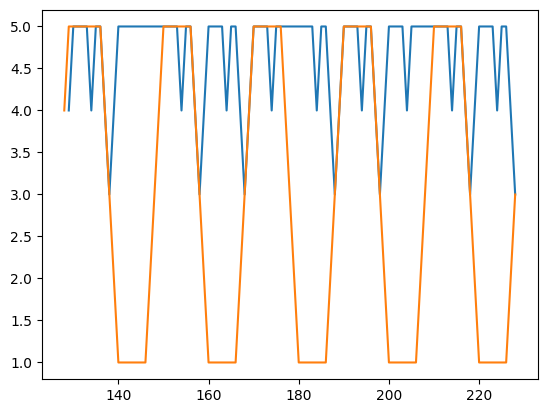

51
(306, 57) (306,)
Train model on 306 examples
Model trained in 0:00:00.346909
256 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.007776000000001488


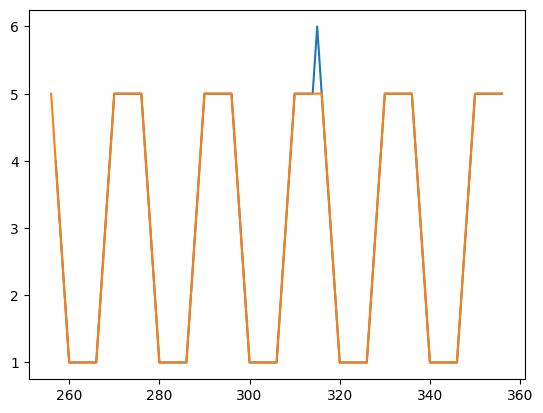

102
(612, 57) (612,)
Train model on 612 examples
Model trained in 0:00:00.199752
512 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


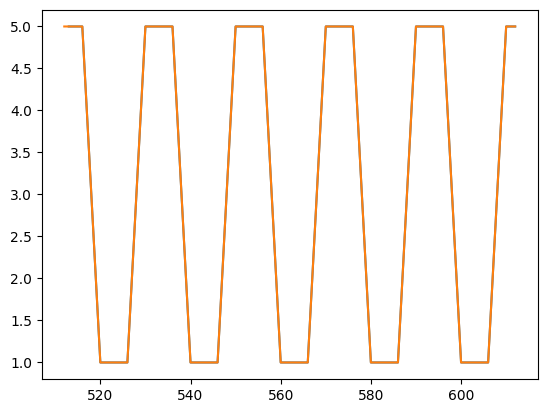

150
(900, 57) (900,)
Train model on 900 examples
Model trained in 0:00:00.857313
750 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0231498000000002


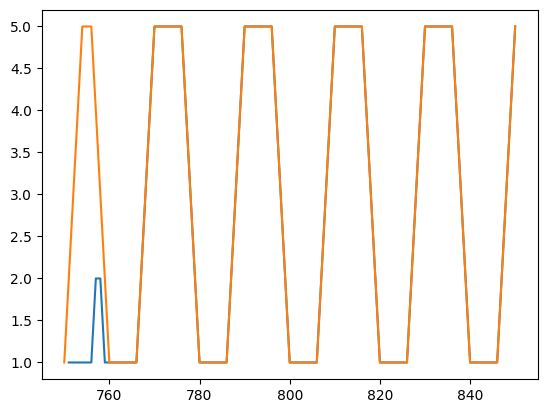

204
(1224, 57) (1224,)
Train model on 1224 examples
Model trained in 0:00:01.322943
1024 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


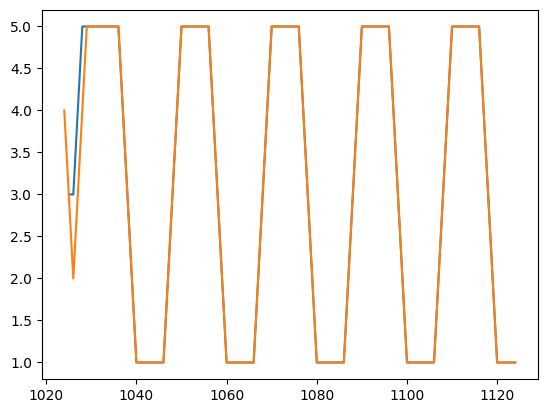

250
(1500, 57) (1500,)
Train model on 1500 examples
Model trained in 0:00:00.424837
1250 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


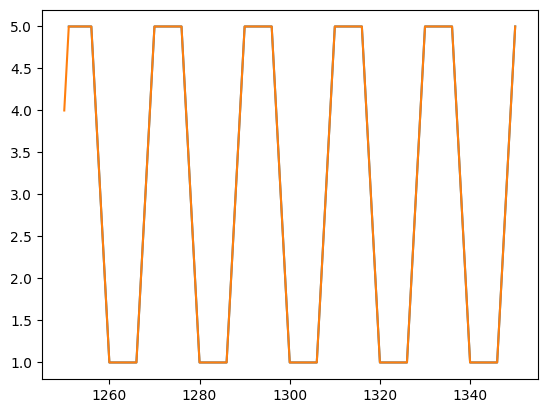

300
(1800, 57) (1800,)
Train model on 1800 examples
Model trained in 0:00:00.307689
1500 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


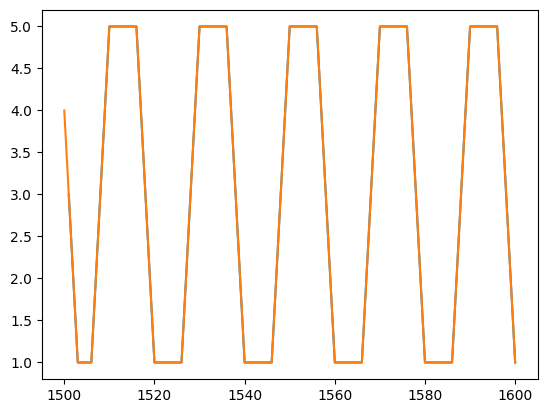

409
(2454, 57) (2454,)
Train model on 2454 examples
Model trained in 0:00:00.985401
2048 train done
0.0


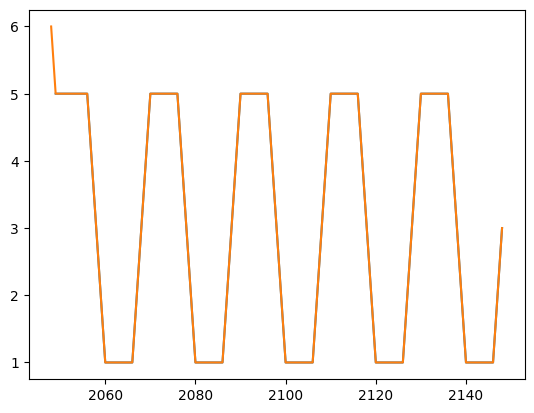

25
(150, 57) (150,)
Train model on 150 examples
Model trained in 0:00:00.918148
128 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.0215620782025774


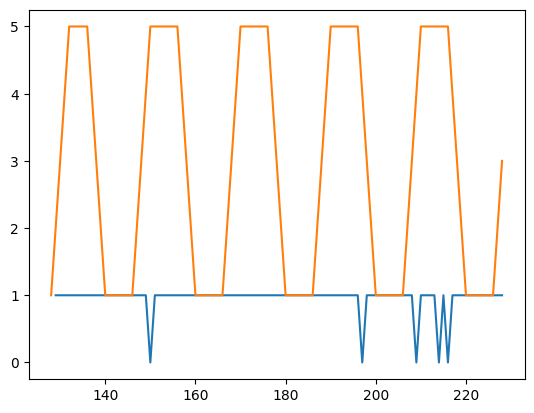

51
(306, 57) (306,)
Train model on 306 examples
Model trained in 0:00:00.154884
256 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.23751484108467794


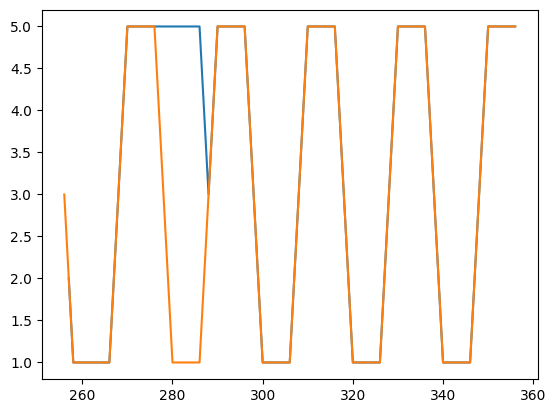

102
(612, 57) (612,)
Train model on 612 examples
Model trained in 0:00:00.214460
512 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.009914400000000115


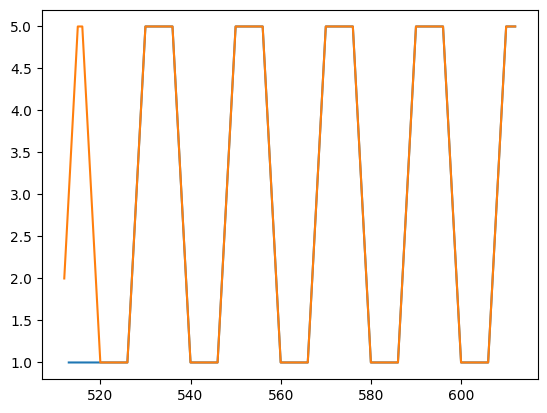

150
(900, 57) (900,)
Train model on 900 examples
Model trained in 0:00:00.759506
750 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


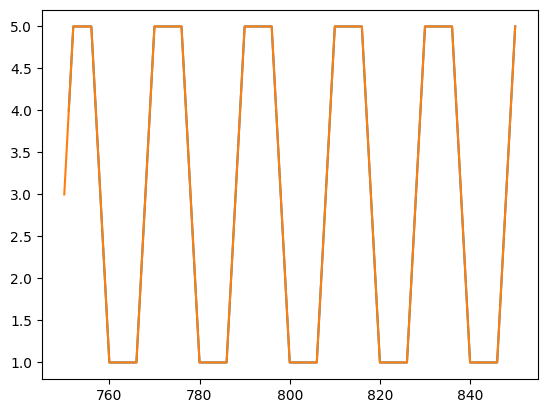

204
(1224, 57) (1224,)
Train model on 1224 examples
Model trained in 0:00:00.818860
1024 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


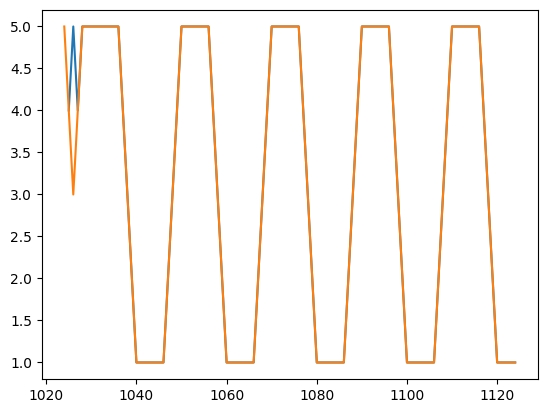

250
(1500, 57) (1500,)
Train model on 1500 examples
Model trained in 0:00:02.356954
1250 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


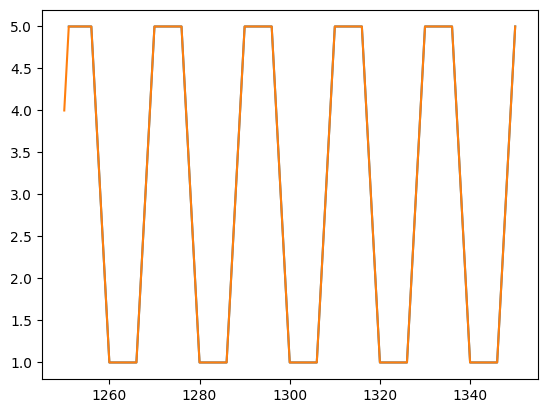

300
(1800, 57) (1800,)
Train model on 1800 examples
Model trained in 0:00:00.456426
1500 train done
0.0


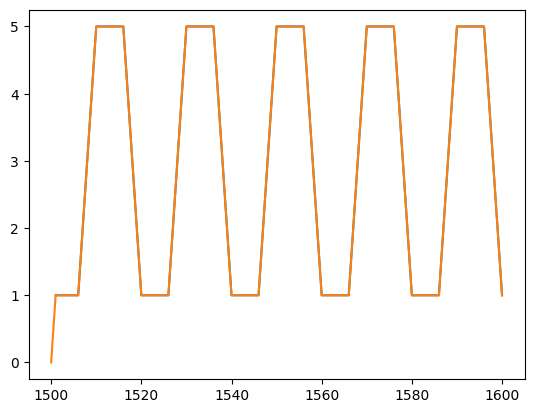

409
(2454, 57) (2454,)
Train model on 2454 examples
Model trained in 0:00:00.388544
2048 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


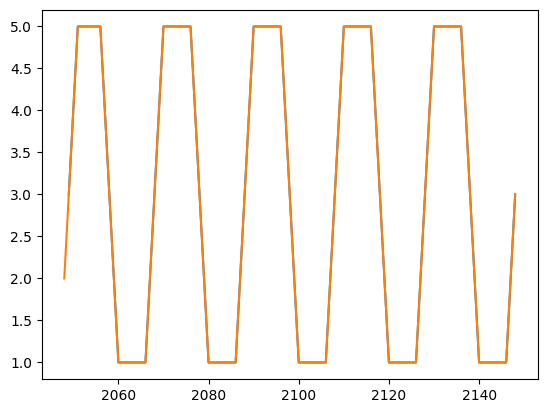

25
(150, 57) (150,)
Train model on 150 examples
Model trained in 0:00:00.085348
128 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.4750313495904271


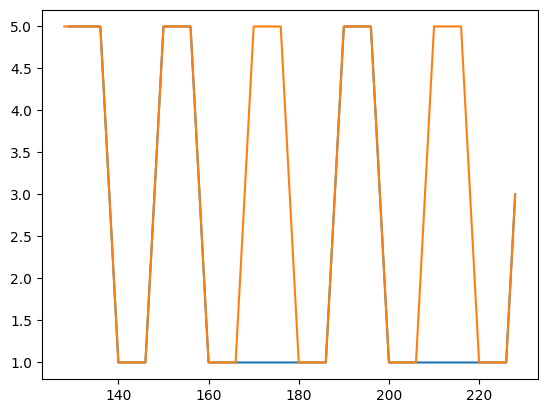

51
(306, 57) (306,)
Train model on 306 examples
Model trained in 0:00:00.202975
256 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.7125511138623781


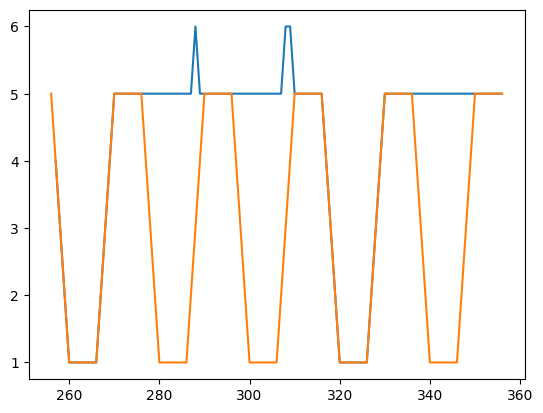

102
(612, 57) (612,)
Train model on 612 examples
Model trained in 0:00:00.380554
512 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


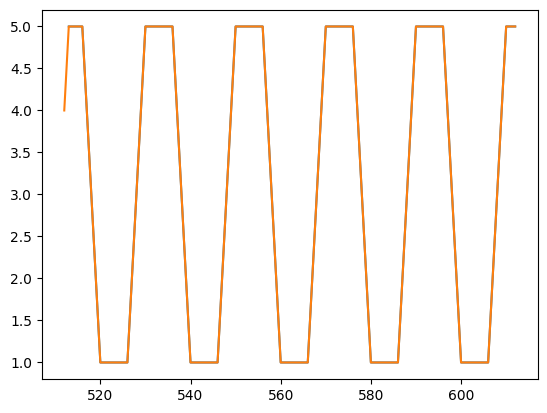

150
(900, 57) (900,)
Train model on 900 examples
Model trained in 0:00:00.285613
750 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


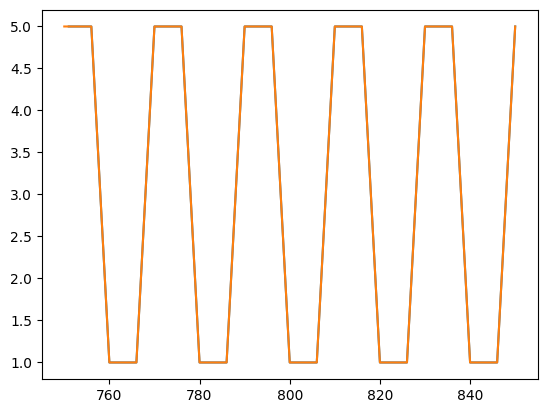

204
(1224, 57) (1224,)
Train model on 1224 examples
Model trained in 0:00:01.979154
1024 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


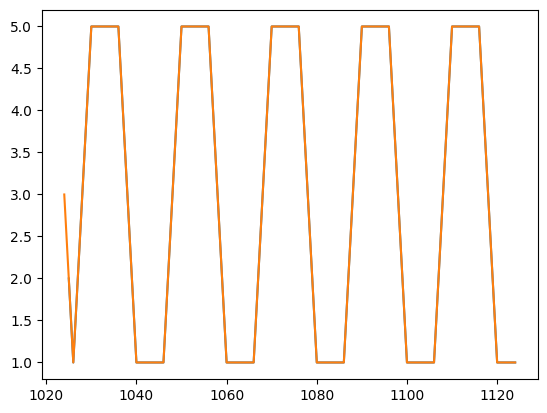

250
(1500, 57) (1500,)
Train model on 1500 examples
Model trained in 0:00:00.636357
1250 train done
0.0


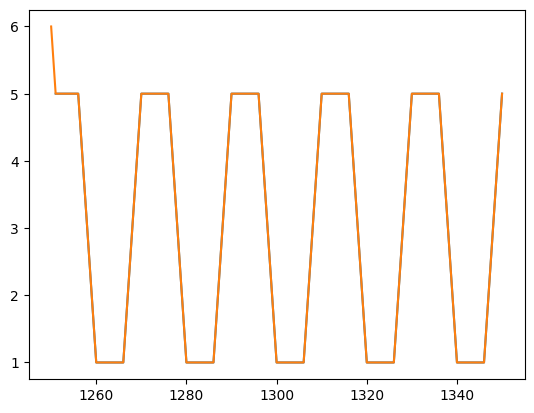

300
(1800, 57) (1800,)
Train model on 1800 examples
Model trained in 0:00:00.767290
1500 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


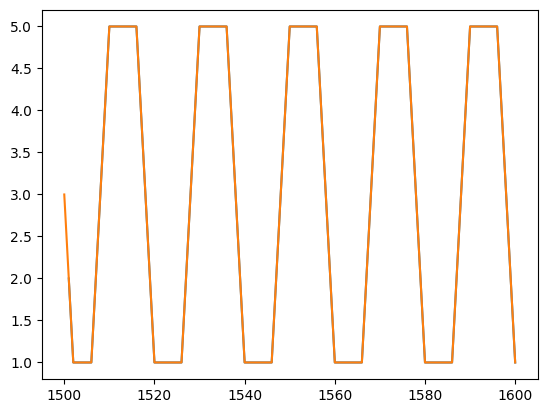

409
(2454, 57) (2454,)
Train model on 2454 examples
Model trained in 0:00:00.799245
2048 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.07658864999999991


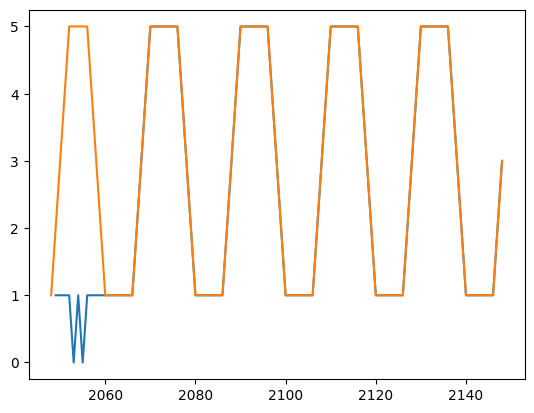

25
(150, 57) (150,)
Train model on 150 examples
Model trained in 0:00:00.145298
128 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.0215620782025774


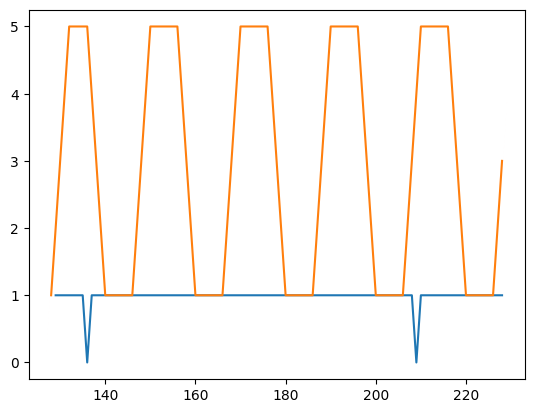

51
(306, 57) (306,)
Train model on 306 examples
Model trained in 0:00:00.106428
256 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.7125511138623781


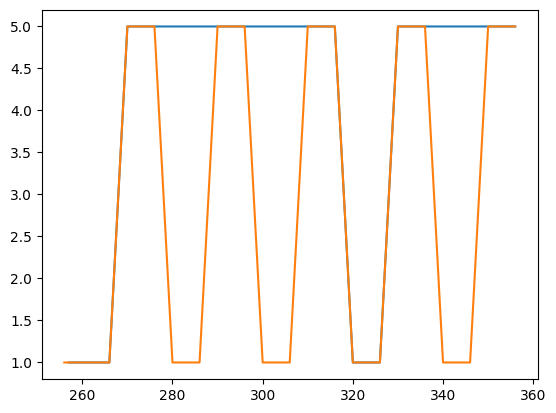

102
(612, 57) (612,)
Train model on 612 examples
Model trained in 0:00:00.752294
512 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.7125437110186758


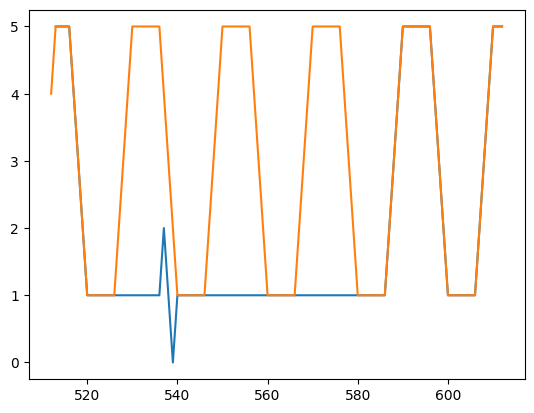

150
(900, 57) (900,)
Train model on 900 examples
Model trained in 0:00:00.221327
750 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.03934980000000024


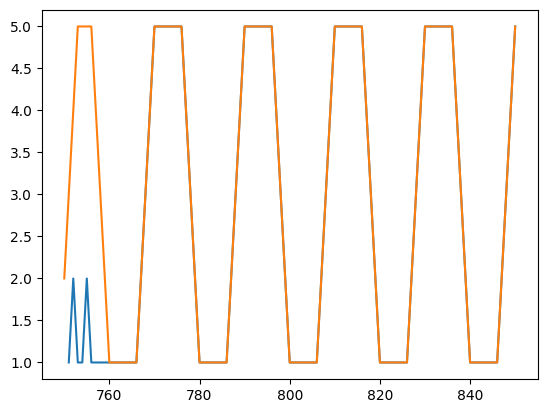

204
(1224, 57) (1224,)
Train model on 1224 examples
Model trained in 0:00:00.566382
1024 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


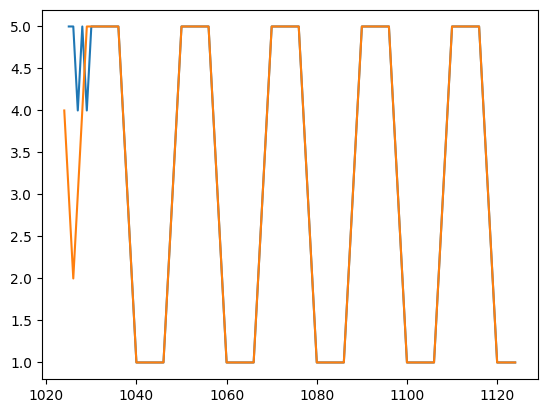

250
(1500, 57) (1500,)
Train model on 1500 examples
Model trained in 0:00:00.254239
1250 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.23729669616406254


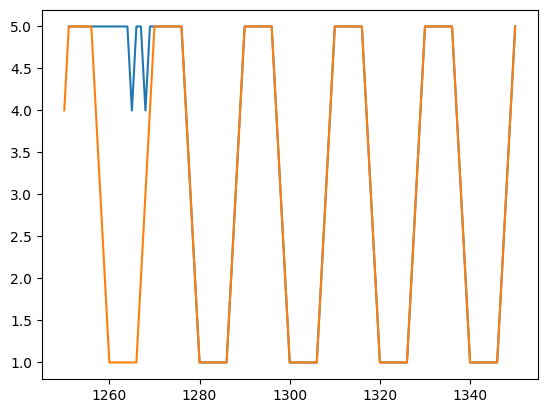

300
(1800, 57) (1800,)
Train model on 1800 examples
Model trained in 0:00:00.509790
1500 train done
0.011809800000000053


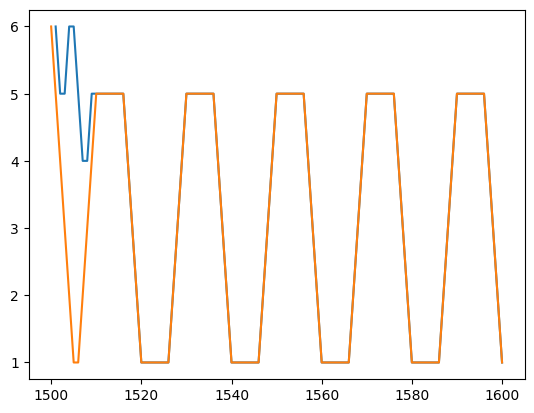

409
(2454, 57) (2454,)
Train model on 2454 examples
Model trained in 0:00:00.970635
2048 train done
0.04508865000000015


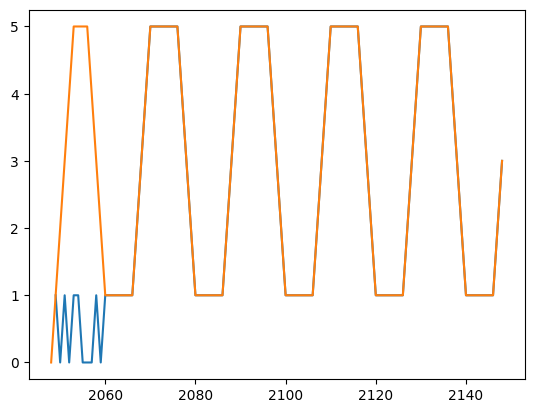

25
(150, 57) (150,)
Train model on 150 examples
Model trained in 0:00:00.174392
128 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.1919653570220814


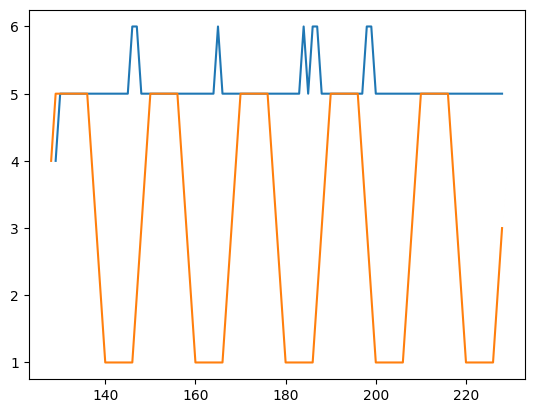

51
(306, 57) (306,)
Train model on 306 examples
Model trained in 0:00:00.243523
256 train done
0.0


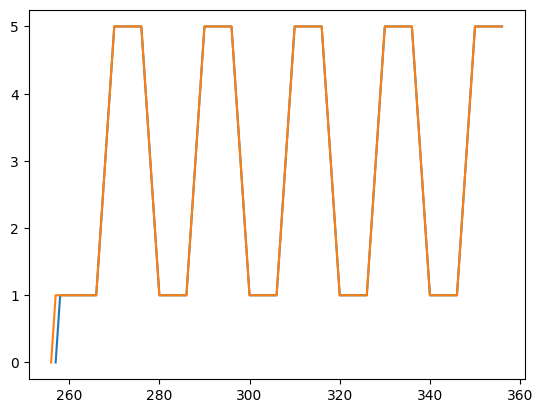

102
(612, 57) (612,)
Train model on 612 examples
Model trained in 0:00:00.263529
512 train done
0.7126498484603232


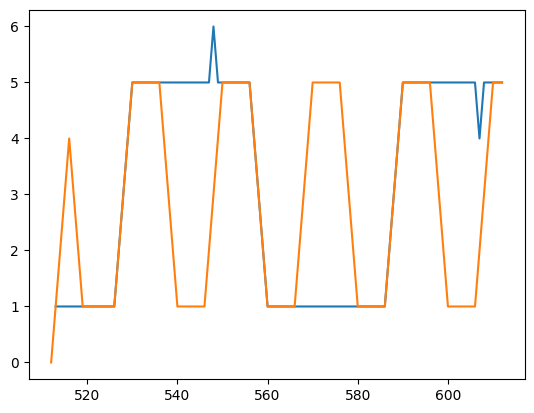

150
(900, 57) (900,)
Train model on 900 examples
Model trained in 0:00:00.215277
750 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


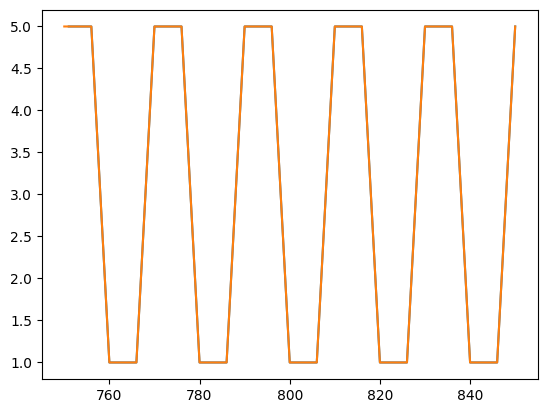

204
(1224, 57) (1224,)
Train model on 1224 examples
Model trained in 0:00:00.197608
1024 train done
0.0


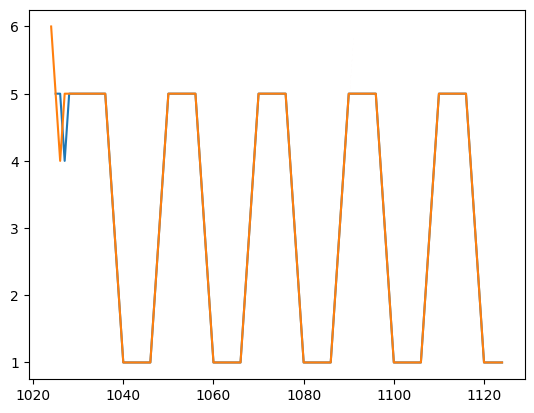

250
(1500, 57) (1500,)
Train model on 1500 examples
Model trained in 0:00:00.351164
1250 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


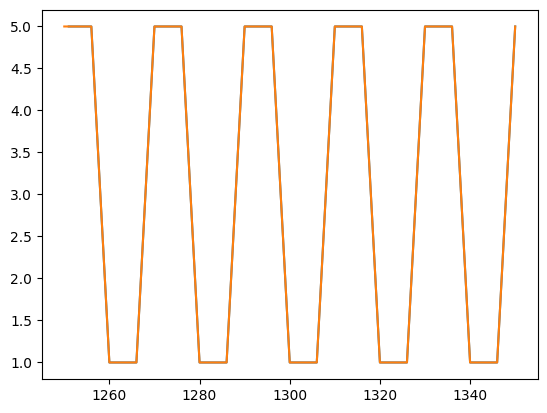

300
(1800, 57) (1800,)
Train model on 1800 examples
Model trained in 0:00:00.403126
1500 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0231498000000002


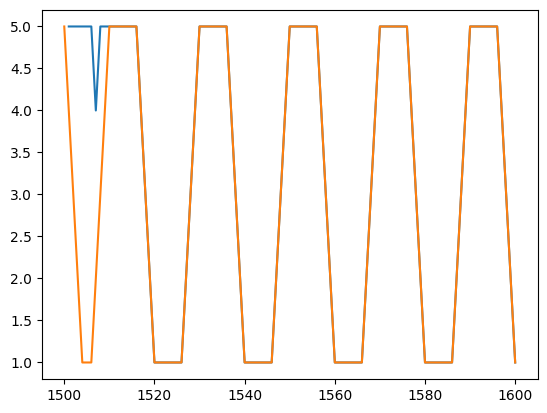

409
(2454, 57) (2454,)
Train model on 2454 examples
Model trained in 0:00:03.258870
2048 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


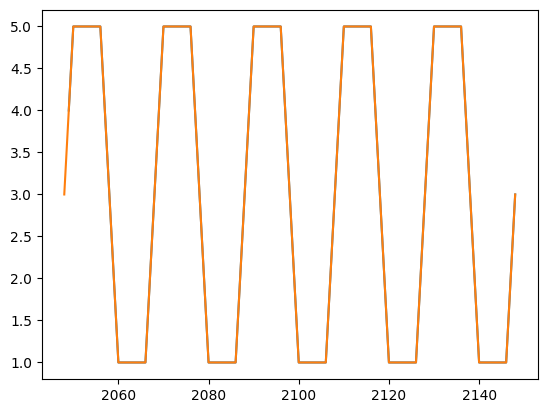

25
(150, 57) (150,)
Train model on 150 examples
Model trained in 0:00:00.080342
128 train done
0.9577757997158218


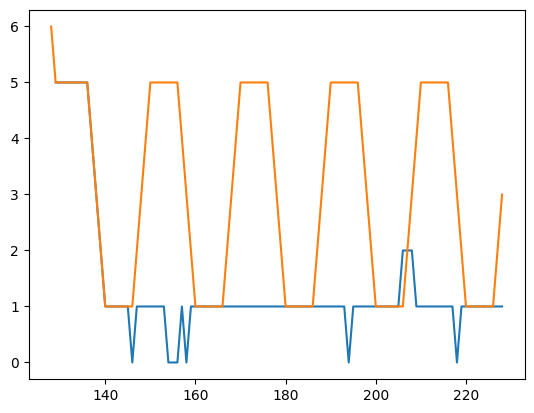

51
(306, 57) (306,)
Train model on 306 examples
Model trained in 0:00:00.587976
256 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.47968167538040546


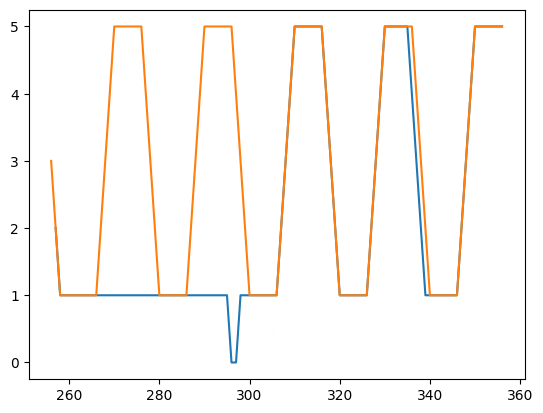

102
(612, 57) (612,)
Train model on 612 examples
Model trained in 0:00:00.194722
512 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.00408239999999978


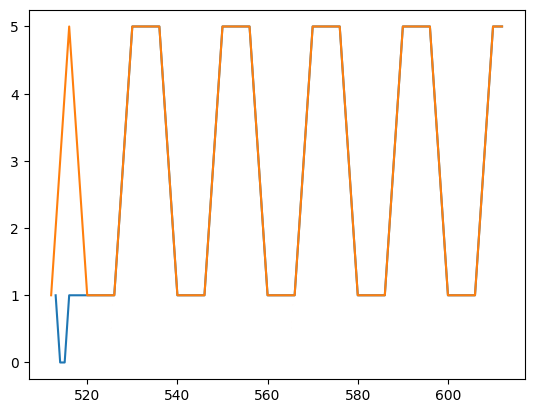

150
(900, 57) (900,)
Train model on 900 examples
Model trained in 0:00:00.443854
750 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


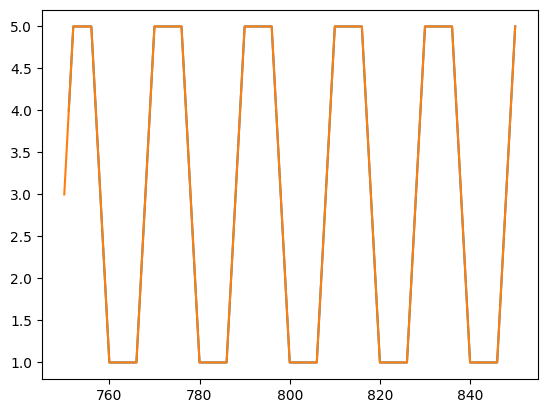

204
(1224, 57) (1224,)
Train model on 1224 examples
Model trained in 0:00:00.272008
1024 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


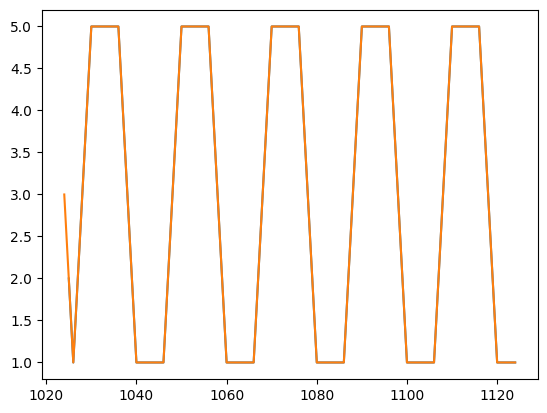

250
(1500, 57) (1500,)
Train model on 1500 examples
Model trained in 0:00:00.486212
1250 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


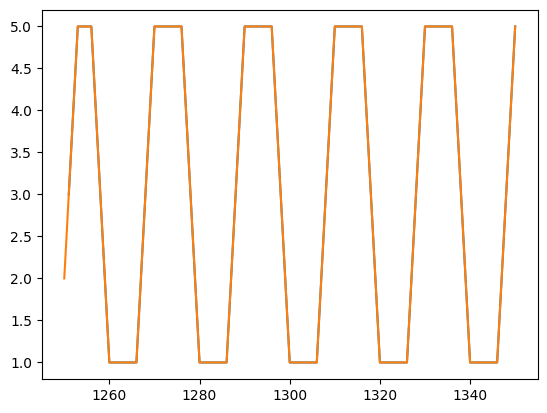

300
(1800, 57) (1800,)
Train model on 1800 examples
Model trained in 0:00:00.471769
1500 train done
0.0


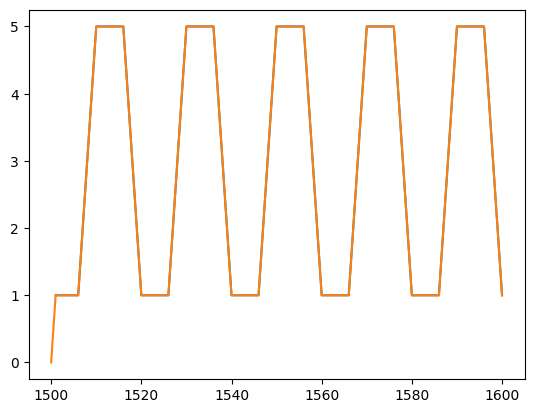

409
(2454, 57) (2454,)
Train model on 2454 examples
Model trained in 0:00:00.392519
2048 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.12158864999999991


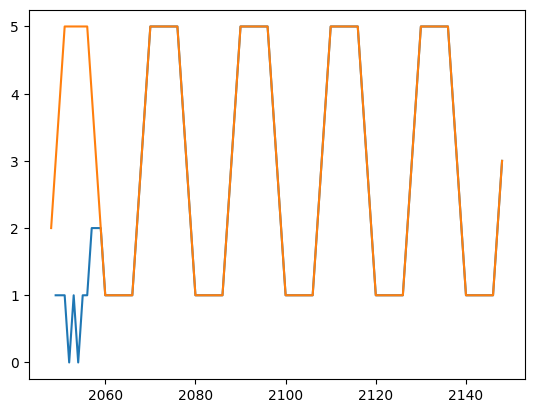

25
(150, 57) (150,)
Train model on 150 examples
Model trained in 0:00:00.089330
128 train done
0.9064468472743861


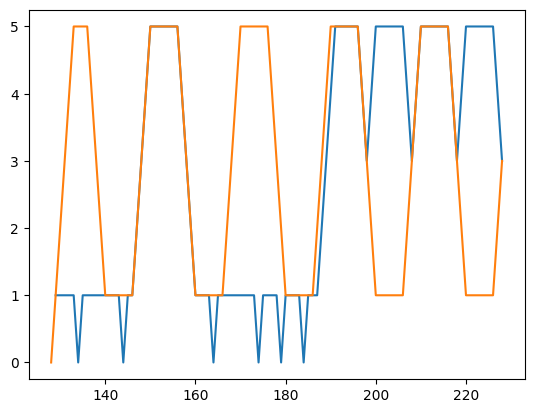

51
(306, 57) (306,)
Train model on 306 examples
Model trained in 0:00:00.203788
256 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


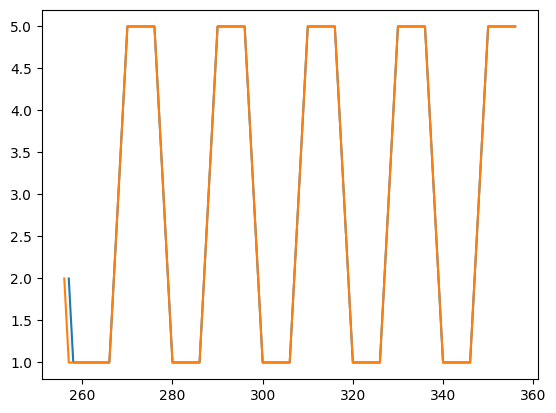

102
(612, 57) (612,)
Train model on 612 examples
Model trained in 0:00:00.759509
512 train done
0.4746751094911758


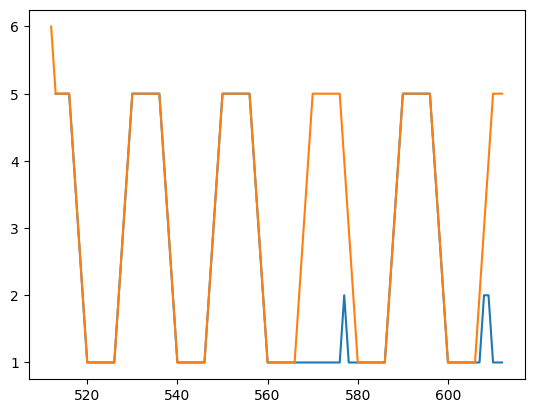

150
(900, 57) (900,)
Train model on 900 examples
Model trained in 0:00:00.339946
750 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


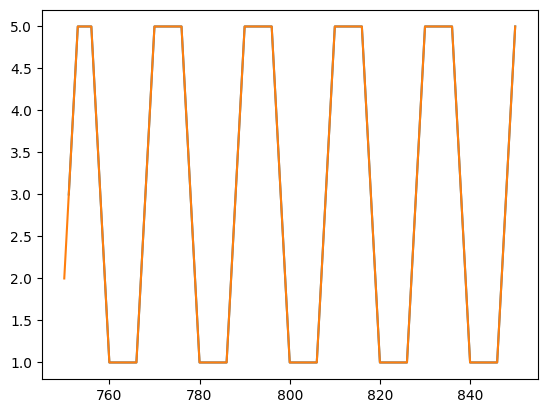

204
(1224, 57) (1224,)
Train model on 1224 examples
Model trained in 0:00:00.689793
1024 train done
0.0


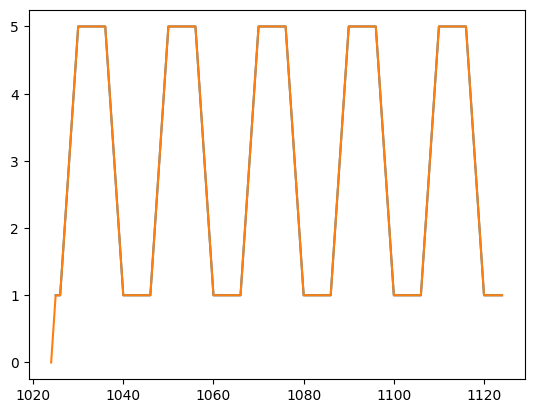

250
(1500, 57) (1500,)
Train model on 1500 examples
Model trained in 0:00:00.372533
1250 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


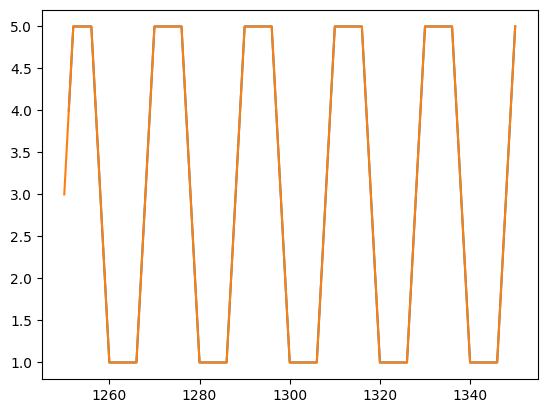

300
(1800, 57) (1800,)
Train model on 1800 examples
Model trained in 0:00:00.721965
1500 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


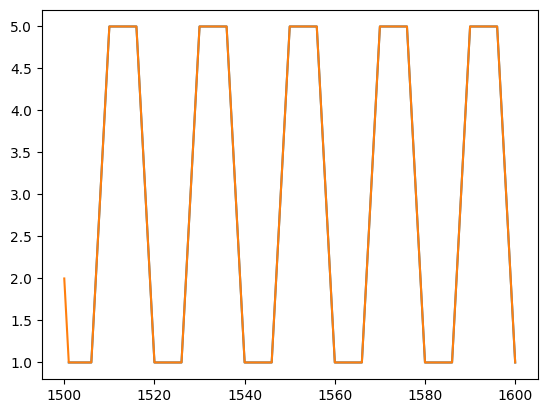

409
(2454, 57) (2454,)
Train model on 2454 examples
Model trained in 0:00:00.964137
2048 train done


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3267319742.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


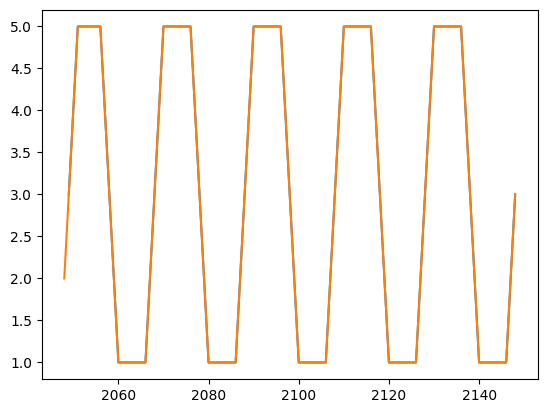

In [ ]:
gamma = 0.5
Ts = [2**i for i in np.arange(7,10)] +[750]+ [1024, 1250, 1500, 2048]

DELTA_t = 5
t_prime = 6
reps = 10
all_seed_results_ydf = {}

for rep in range(reps):
    seed = 515 +rep
    np.random.seed(seed)
    all_seed_results_ydf[seed] = {}
    FUTURE_STATE = []
    for T in Ts:
        n_seq = int(T/DELTA_t)
    # n_seq = T
        print(n_seq)
        state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
        time_raw = np.random.choice([int(i) for i in range(T)],size = n_seq)
        opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
        STATES = []
        for i in range(len(time_raw)):
            path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
        # print(state_raw[i],path)
            times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
            opt_paths.append(path)
            opt_irewards.append(rewards)
            opt_times.append(times)
            opt_prewards.append(preward_opt(rewards,gamma = 0.5))
            state_posencode_oh = position_encoder(np.array(path), type="onehot")
            time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
        # print(time_emb.shape,state_posencode_oh.shape)
            state_pe = np.hstack([state_posencode_oh,time_emb])
            STATES.append(state_pe)
        STATES_arr = np.vstack(STATES)
        REWARDS_arr = np.hstack(np.array(opt_irewards).reshape(-1,1))
        print(STATES_arr.shape,REWARDS_arr.shape)
    # plt.plot(opt_times[0],opt_paths[0])
    # plt.show()
    # plt.plot(opt_times[0],opt_irewards[0])
    # plt.show()
        X_train = STATES_arr
        Y_train = REWARDS_arr

        df_train = pd.DataFrame(X_train)
        feature_labels = [f'feature_{i}' for i in range(X_train.shape[1])]
        df_train.columns = feature_labels
        df_train['target'] = Y_train
        rf = GradientBoostedTreesLearner(label = 'target', task = ydf.Task.REGRESSION, num_trees=1000, random_seed=seed)
        model = rf.train(df_train)
        print(T,'train done')

    
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
    # print(current_state)
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                features_pd = pd.DataFrame(features, columns = feature_labels)
                irewards_pred[:,i] = model.predict(features_pd)
            reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
        # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

        # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
        # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
        # print(df_all_paths.iloc[bext_idx,:])
            future_states.append(next_state)
            current_state = next_state
    
    # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()
    all_seed_results_ydf[seed][t_prime] = FUTURE_STATE.copy()




Processing seed: 515
Processing seed: 516
Processing seed: 517
Processing seed: 518
Processing seed: 519
Processing seed: 520
Processing seed: 521
Processing seed: 522
Processing seed: 523
Processing seed: 524
Pregrets shape: (10, 8)
Mean pregrets: [1.03388546 0.42962754 0.39109665 0.02565369 0.02385192 0.02997963
 0.00462996 0.02883546]


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_51173/3209293595.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


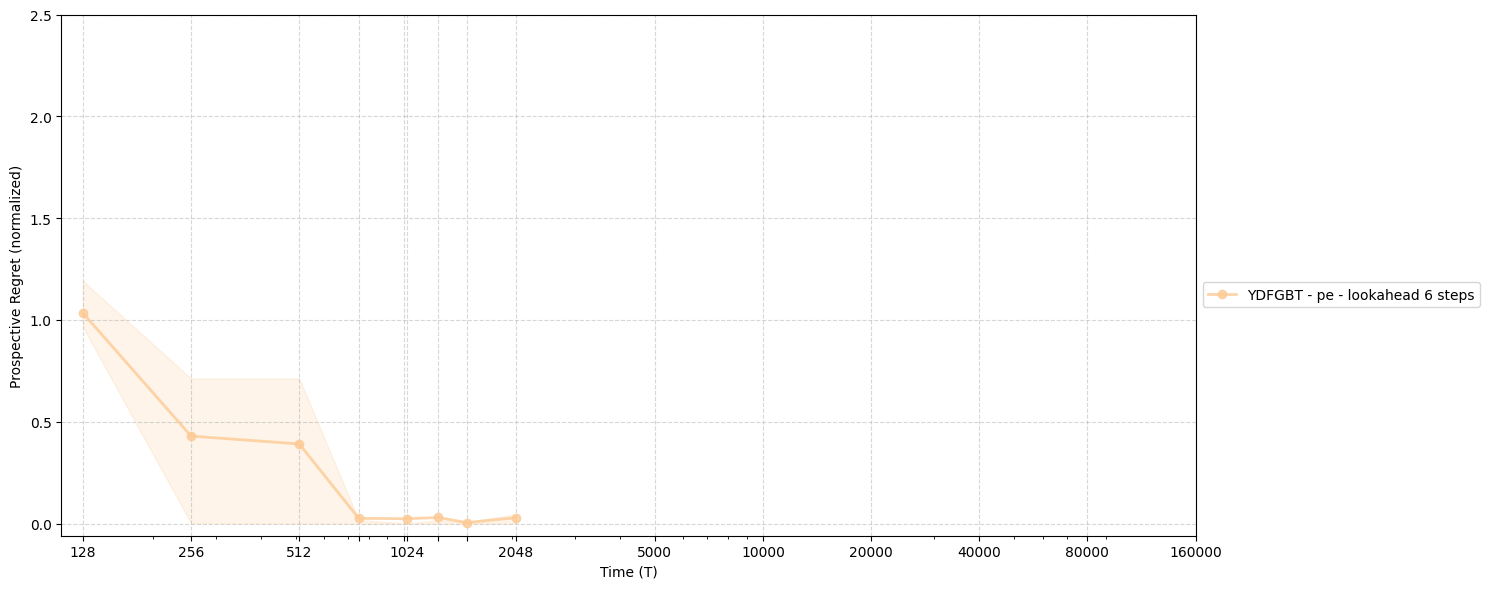

In [6]:
from matplotlib import cm

def get_close_colors(cmap_name, start=0.5, delta=0.15, n=2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

pafm_pe_orf, pafm_oh_orf, pafm_pe, pafm_oh = get_close_colors("PuRd", start=0.1, delta=0.25, n=4)
skgbt_pe, skgbt_oh = get_close_colors("GnBu", start=0.1, delta=0.2, n=2) 
ydfgbt_pe, ydfgbt_oh = get_close_colors("YlOrBr", start=0.9, delta=0.2, n=2) 
ydfrf_pe, ydfrf_oh = get_close_colors("OrRd", start=0.1, delta=0.2, n=2) 

colors = {
    "YDFRF_pe": ydfrf_pe,
    "YDFRF_oh": ydfrf_oh
}

t_prime = 6
Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
seeds = [515, 516, 517, 518, 519, 520, 521, 522, 523, 524]

all_pregrets = []
all_prewards = []

for seed in seeds:
    print(f"Processing seed: {seed}")
    
    # Get the FUTURE_STATE data for this seed
    future_states_list = all_seed_results_ydf[seed][t_prime]
    
    prewards = []
    pregrets = []
    
    for k, T in enumerate(Ts):
        if k < len(future_states_list):
            # Get the future states for this T value
            states_trajectory = future_states_list[k]
            
            irewards = [reward_simulate(states_trajectory[i], T+i, rewards_in_period) 
                       for i in range(1, len(states_trajectory))]
            
            preward = compute_normalized_future_rewards(irewards, 100, 0.5)
            
            path, ireward_opt = path_opt(states_trajectory[0], T, 100)
            preward_opt = compute_normalized_future_rewards(ireward_opt[1:], 100, 0.5)
            
            pregret = (np.sum(preward_opt).item() - np.sum(preward).item()) / 100
            
            prewards.append(np.sum(preward).item())
            pregrets.append(pregret)
        else:
            print(f"Warning: No data for T={T} in seed {seed}")
            prewards.append(np.nan)
            pregrets.append(np.nan)
    
    all_prewards.append(prewards)
    all_pregrets.append(pregrets)
PREWARDS_arr = np.array(all_prewards)
PREGRETS_arr = np.array(all_pregrets)

# Calculate mean and percentiles across seeds
PREGRETS_mean = np.nanmean(PREGRETS_arr, axis=0)
PREGRETS_25th = np.nanpercentile(PREGRETS_arr, 25, axis=0)
PREGRETS_75th = np.nanpercentile(PREGRETS_arr, 75, axis=0)

print(f"Pregrets shape: {PREGRETS_arr.shape}")
print(f"Mean pregrets: {PREGRETS_mean}")

plt.figure(figsize=(15, 6))

plt.plot(Ts, PREGRETS_mean, alpha=0.8, marker='o', color=colors["YDFRF_oh"], 
         label='YDFGBT - pe - lookahead 6 steps', linewidth=2, markersize=6)

plt.fill_between(Ts, PREGRETS_25th, PREGRETS_75th, 
                 alpha=0.2, color=colors["YDFRF_oh"])

Ts_PAFM = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
Ts_PVFM = [1000,5000,10000,20000,40000,80000,160000]

plt.xlabel("Time (T)")
plt.ylabel("Prospective Regret (normalized)")
plt.xscale('log')
xticks = Ts_PAFM + Ts_PVFM
xticklabels = [str(v) if v in [128,256,512,1024,2048,5000,10000,20000,40000,80000,160000] else ""
               for i, v in enumerate(xticks)]
plt.xticks(xticks, labels=xticklabels)
plt.yticks([0,0.5,1,1.5,2,2.5])

plt.legend(loc="upper left", bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
